In [81]:
# Cell 1: Imports

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
import optuna



In [82]:
# Cell 2: Load dataset

data = pd.read_csv("..\data\processed\cleaned.csv")

print(data.shape)
data.head()

(7043, 46)


<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Niku\AppData\Local\Temp\ipykernel_39932\1448316169.py:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  data = pd.read_csv("..\data\processed\cleaned.csv")


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,1,29.85,29.85,True,False,False,True,True,False,...,True,False,False,False,True,False,False,True,False,0
1,0,34,56.95,1889.50,False,True,True,False,True,False,...,False,True,False,True,False,False,False,False,True,0
2,0,2,53.85,108.15,False,True,True,False,True,False,...,True,False,False,False,True,False,False,False,True,1
3,0,45,42.30,1840.75,False,True,True,False,True,False,...,False,True,False,True,False,True,False,False,False,0
4,0,2,70.70,151.65,True,False,True,False,True,False,...,True,False,False,False,True,False,False,True,False,1


In [83]:
# Cell 3: Split

X = data.drop(columns=["Churn"])
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(5634, 45) (1409, 45)


In [84]:
# Cell 4: Drop redundant one-hot columns

cols_to_drop = [
    "gender_Female",
    "Partner_No",
    "Dependents_No",
    "PhoneService_No",
    "PaperlessBilling_No",
    "Contract_One year",
    "PaymentMethod_Mailed check"
]

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [ ]:
# Cell 5: Feature engineering functions

def add_features(df):
    df = df.copy()

    # --- Core features ---
    df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)
    df["ChargePerTenure"] = df["MonthlyCharges"] / (df["tenure"] + 1)
    df["CLV_proxy"] = df["tenure"] * df["MonthlyCharges"]

    # --- Risk flags ---
    df["IsMonthToMonth"] = df["Contract_Month-to-month"]
    df["IsFiber"] = df["InternetService_Fiber optic"]
    df["IsElectronicPayment"] = df["PaymentMethod_Electronic check"]

    # --- Interactions ---
    df["MM_Paperless"] = df["Contract_Month-to-month"] * df["PaperlessBilling_Yes"]
    df["Fiber_HighCharge"] = df["InternetService_Fiber optic"] * (
        df["MonthlyCharges"] > df["MonthlyCharges"].median()
    )
    df["Tenure_Charge"] = df["tenure"] * df["MonthlyCharges"]

    # --- Nonlinear transforms ---
    df["log_tenure"] = np.log1p(df["tenure"])
    df["log_totalcharges"] = np.log1p(df["TotalCharges"])

    # --- Binning ---
    df["TenureGroup"] = pd.cut(df["tenure"], bins=[0,12,24,48,72], labels=[0,1,2,3])
    df["ChargeGroup"] = pd.qcut(df["MonthlyCharges"], q=4, labels=False, duplicates="drop")
    df["Fiber_MonthToMonth"] = (
    df["InternetService_Fiber optic"] * df["Contract_Month-to-month"]
)

    df["NoSecurity"] = (df["OnlineSecurity_No"] == 1).astype(int)
    df["NoTechSupport"] = (df["TechSupport_No"] == 1).astype(int)

    df["HighCharge"] = (df["MonthlyCharges"] > 70).astype(int)
    df["LowTenure"] = (df["tenure"] < 6).astype(int)

    df["LowTenure"] = (df["tenure"] < 6).astype(int)
    df["HighCharge"] = (df["MonthlyCharges"] > 70).astype(int)
    df["NoSupport"] = (df["TechSupport_No"] == 1).astype(int)
    df["NoSecurity"] = (df["OnlineSecurity_No"] == 1).astype(int)

    df["Fiber_Month"] = df["InternetService_Fiber optic"] * df["Contract_Month-to-month"]
    return df

In [86]:
# Cell 6: Apply features

X_train = add_features(X_train)
X_test = add_features(X_test)

# Fill any NaNs from binning/division
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

for col in X_train.select_dtypes(include=["category"]).columns:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)

In [87]:
# Cell 7: Scaling

scaler = StandardScaler()

num_cols = X_train.select_dtypes(include=np.number).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [88]:
# Cell 8: Evaluation

def evaluate_model(model):
    model.fit(X_train, y_train)

    train_preds = model.predict_proba(X_train)[:,1]
    test_preds = model.predict_proba(X_test)[:,1]

    train_auc = roc_auc_score(y_train, train_preds)
    test_auc = roc_auc_score(y_test, test_preds)

    print(f"Train AUC: {train_auc:.4f}")
    print(f"Test AUC:  {test_auc:.4f}")

    return test_auc

In [89]:
# Cell 9: Logistic Regression

lr = LogisticRegression(max_iter=1000)
print("Logistic Regression:")
lr_auc = evaluate_model(lr)

Logistic Regression:
Train AUC: 0.8542
Test AUC:  0.8470


In [90]:
# Cell 10: Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

print("Random Forest:")
rf_auc = evaluate_model(rf)

Random Forest:
Train AUC: 0.9207
Test AUC:  0.8439


In [91]:
# Cell 11: XGBoost baseline

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

print("XGBoost Baseline:")
xgb_auc = evaluate_model(xgb_model)

XGBoost Baseline:
Train AUC: 0.9452
Test AUC:  0.8364


In [92]:
# Cell 12: Optuna objective

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)

    preds = model.predict_proba(X_test)[:,1]
    return roc_auc_score(y_test, preds)

In [93]:
# Cell 13: Run Optuna

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best AUC:", study.best_value)

[I 2026-04-17 14:50:15,770] A new study created in memory with name: no-name-75a8541f-e626-441c-91c6-406314952bfb
Best trial: 0. Best value: 0.842385:   1%|          | 1/100 [00:00<00:18,  5.28it/s]

[I 2026-04-17 14:50:15,960] Trial 0 finished with value: 0.8423854917461054 and parameters: {'n_estimators': 517, 'max_depth': 9, 'learning_rate': 0.17617912347943698, 'subsample': 0.6780613901534638, 'colsample_bytree': 0.9467967357332728, 'gamma': 1.6426462835049427, 'reg_alpha': 4.224229940866286, 'reg_lambda': 1.0874638807100996}. Best is trial 0 with value: 0.8423854917461054.


Best trial: 2. Best value: 0.848136:   3%|▎         | 3/100 [00:00<00:20,  4.81it/s]

[I 2026-04-17 14:50:16,291] Trial 1 finished with value: 0.8361905500012917 and parameters: {'n_estimators': 756, 'max_depth': 8, 'learning_rate': 0.08837885972517313, 'subsample': 0.9321473507828345, 'colsample_bytree': 0.8615100552731378, 'gamma': 0.432748549911518, 'reg_alpha': 2.956895844757437, 'reg_lambda': 1.404858307617648}. Best is trial 0 with value: 0.8423854917461054.
[I 2026-04-17 14:50:16,422] Trial 2 finished with value: 0.8481360923816167 and parameters: {'n_estimators': 449, 'max_depth': 6, 'learning_rate': 0.17901220617061508, 'subsample': 0.9691661854500336, 'colsample_bytree': 0.6837084454739925, 'gamma': 4.901757802596052, 'reg_alpha': 1.0678378367323877, 'reg_lambda': 0.1503208051407401}. Best is trial 2 with value: 0.8481360923816167.


Best trial: 2. Best value: 0.848136:   4%|▍         | 4/100 [00:00<00:21,  4.47it/s]

...

[I 2026-04-17 14:50:40,541] Trial 96 finished with value: 0.8479849647368829 and parameters: {'n_estimators': 863, 'max_depth': 8, 'learning_rate': 0.16707401011036993, 'subsample': 0.7590120542357971, 'colsample_bytree': 0.9770430870069541, 'gamma': 4.656511095727547, 'reg_alpha': 2.8279270012167843, 'reg_lambda': 4.241159150052288}. Best is trial 87 with value: 0.8510113926993722.
[I 2026-04-17 14:50:40,658] Trial 97 finished with value: 0.8472112428634168 and parameters: {'n_estimators': 375, 'max_depth': 10, 'learning_rate': 0.15432898017459884, 'subsample': 0.8256484842603946, 'colsample_bytree': 0.9452507451395464, 'gamma': 4.472813644172364, 'reg_alpha': 2.434969945371407, 'reg_lambda': 1.051903487033322}. Best is trial 87 with value: 0.8510113926993722.


Best trial: 87. Best value: 0.851011:  99%|█████████▉| 99/100 [00:25<00:00,  4.38it/s]

[I 2026-04-17 14:50:40,885] Trial 98 finished with value: 0.8486359761295822 and parameters: {'n_estimators': 844, 'max_depth': 5, 'learning_rate': 0.17306451803380524, 'subsample': 0.6598756288145364, 'colsample_bytree': 0.9680322729175806, 'gamma': 4.993414248057888, 'reg_alpha': 1.5315744685594508, 'reg_lambda': 4.904497427222794}. Best is trial 87 with value: 0.8510113926993722.


Best trial: 87. Best value: 0.851011: 100%|██████████| 100/100 [00:25<00:00,  3.93it/s]

[I 2026-04-17 14:50:41,219] Trial 99 finished with value: 0.8402658296520189 and parameters: {'n_estimators': 904, 'max_depth': 7, 'learning_rate': 0.1497052158376278, 'subsample': 0.8091586349554024, 'colsample_bytree': 0.8450926797532246, 'gamma': 1.3324149708169994, 'reg_alpha': 2.3231576812522015, 'reg_lambda': 4.639995177409473}. Best is trial 87 with value: 0.8510113926993722.
Best params: {'n_estimators': 899, 'max_depth': 5, 'learning_rate': 0.18362355612067627, 'subsample': 0.7033297851504949, 'colsample_bytree': 0.9497282732103487, 'gamma': 4.778979287627902, 'reg_alpha': 1.8667516677139298, 'reg_lambda': 0.3109136293145829}
Best AUC: 0.8510113926993722


In [94]:
# Cell 14: Final model

final_model = xgb.XGBClassifier(
    **study.best_params,
    eval_metric="logloss",
    random_state=42
)

final_auc = evaluate_model(final_model)

Train AUC: 0.8706
Test AUC:  0.8510


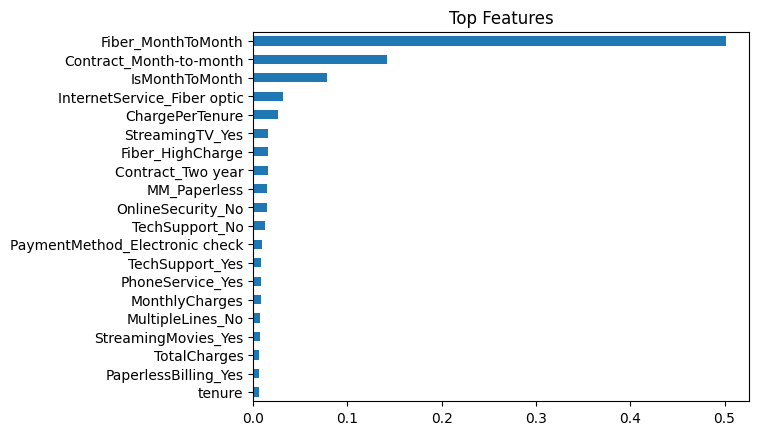

In [95]:
# Cell 15: Feature importance

import matplotlib.pyplot as plt

feat_imp = pd.Series(
    final_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feat_imp.head(20).plot(kind="barh")
plt.title("Top Features")
plt.gca().invert_yaxis()
plt.show()

In [96]:
# Cell 16: Threshold tuning

probs = final_model.predict_proba(X_test)[:,1]

thresholds = np.linspace(0.1, 0.9, 50)

best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)

Best threshold: 0.36122448979591837
Best F1: 0.6390532544378699


In [97]:
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": scale_pos_weight,
        "tree_method": "hist",

        
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)

    preds = model.predict_proba(X_test)[:,1]
    return roc_auc_score(y_test, preds)

In [98]:
#so our model is pretty bad, based on F1 score. we can remove low-signal features, and also try to balance the dataset (we have 25% churn to 75% non-churn)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
cols_to_drop_extra = [
    "PhoneService_Yes",
    "gender_Male",
    "StreamingTV_Yes",
    "StreamingMovies_Yes",
    "MultipleLines_Yes",
    "InternetService_DSL"
]

X_train = X_train.drop(columns=[c for c in cols_to_drop_extra if c in X_train.columns])
X_test = X_test.drop(columns=[c for c in cols_to_drop_extra if c in X_test.columns])
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After:", pd.Series(y_train_sm).value_counts())


Before: Churn
0    4139
1    1495
Name: count, dtype: int64
After: Churn
0    4139
1    4139
Name: count, dtype: int64


In [99]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42
)
xgb_model.fit(X_train_sm, y_train_sm)
evaluate_model(xgb_model)

Train AUC: 0.8788
Test AUC:  0.8447


0.8447415329768271

In [100]:

probs = xgb_model.predict_proba(X_test)[:,1]

thresholds = np.linspace(0.1, 0.9, 50)

best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)

Best threshold: 0.3285714285714286
Best F1: 0.632768361581921


In [101]:
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    gamma=1.5,
    reg_alpha=1,
    reg_lambda=3,
    tree_method="hist",
    random_state=42
)

probs = xgb_model.predict_proba(X_test)[:,1]

thresholds = np.linspace(0.1, 0.9, 100)

best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(best_thresh, best_f1)



0.29393939393939394 0.6335135135135135


In [102]:
#getting decent AUC, without overfitting, but still low F1. I think either precision or recall is our bottleneck

In [103]:
from sklearn.metrics import classification_report

probs = xgb_model.predict_proba(X_test)[:,1]
preds = (probs > 0.5).astype(int)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [104]:
#model is too conservative, as seen by incredibly low recall (can't catch most churners) going to try
#lowering the threshold


In [105]:

probs = xgb_model.predict_proba(X_test)[:,1]
preds = (probs > 0.25).astype(int)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.51      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.75      1409



In [106]:
thresholds = np.linspace(0.1, 0.5, 100)

best_f1 = 0

for t in thresholds:
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.29393939393939394
Best F1: 0.6335135135135135


In [107]:

probs = xgb_model.predict_proba(X_test)[:,1]
preds = (probs > 0.31).astype(int)

print(classification_report(y_test, preds))

thresholds = np.linspace(0.1, 0.9, 50)

best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)


              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



Best threshold: 0.3285714285714286
Best F1: 0.632768361581921


In [108]:
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.7,
    scale_pos_weight=scale_pos_weight * 1.5,
    gamma=2,
    reg_alpha=2,
    reg_lambda=4,
    tree_method="hist",
    random_state=42
)

model.fit(X_train_sm, y_train_sm)
evaluate_model(model)

Train AUC: 0.8756
Test AUC:  0.8454


0.8453589604484746

In [109]:
final_preds = (probs > best_t).astype(int)

print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [122]:
#looks like there may be noisy features, because changing our threshold simply gives the tradeoff in precision vs recall.
feat_imp = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = feat_imp.head(30).index

X_train = X_train[top_features]
X_test = X_test[top_features]

In [123]:
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.7,
    scale_pos_weight=scale_pos_weight * 1.5,
    gamma=2,
    reg_alpha=2,
    reg_lambda=4,
    tree_method="hist",
    random_state=42
)

model.fit(X_train, y_train)
evaluate_model(model)

Train AUC: 0.8515
Test AUC:  0.8334


0.8334017928647084

In [ ]:

probs = model.predict_proba(X_test)[:,1]
preds = (probs > 0.622).astype(int)

print(classification_report(y_test, preds))

thresholds = np.linspace(0.1, 0.9, 50)

best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)


              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409

Best threshold: 0.6387755102040816
Best F1: 0.6262403528114664


In [125]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

def objective(trial):

    # -----------------------
    # 1. Hyperparameters
    # -----------------------
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "gamma": trial.suggest_float("gamma", 0.5, 3),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.5, 3),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 5),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 5),
        "eval_metric": "logloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1
    }

    # -----------------------
    # 2. Feature Selection
    # -----------------------
    feature_mask = []
    selected_features = []

    for col in X_train.columns:
        use_feature = trial.suggest_categorical(f"feature_{col}", [0, 1])
        feature_mask.append(use_feature)

    selected_features = [
        col for col, use in zip(X_train.columns, feature_mask) if use == 1
    ]

    # Avoid empty feature set
    if len(selected_features) < 5:
        return 0

    X = X_train[selected_features]
    y = y_train

    # -----------------------
    # 3. Cross Validation
    # -----------------------
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    f1_scores = []

    for train_idx, val_idx in skf.split(X, y):

        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(**params)

        model.fit(X_tr, y_tr)

        probs = model.predict_proba(X_val)[:,1]

        # -----------------------
        # 4. Threshold Optimization INSIDE CV
        # -----------------------
        thresholds = np.linspace(0.2, 0.5, 50)

        best_fold_f1 = 0

        for t in thresholds:
            preds = (probs > t).astype(int)
            f1 = f1_score(y_val, preds)

            if f1 > best_fold_f1:
                best_fold_f1 = f1

        f1_scores.append(best_fold_f1)

    return np.mean(f1_scores)

In [126]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best F1:", study.best_value)
print("Best params:", study.best_params)

[I 2026-04-17 14:53:59,334] A new study created in memory with name: no-name-8f5b2004-7282-4c3f-9bf5-d5cbed3d7ff6
Best trial: 0. Best value: 0.577095:   1%|          | 1/100 [00:00<01:20,  1.23it/s]

[I 2026-04-17 14:54:00,148] Trial 0 finished with value: 0.5770949724164269 and parameters: {'n_estimators': 378, 'max_depth': 6, 'learning_rate': 0.01668699758704998, 'subsample': 0.8416199298560552, 'colsample_bytree': 0.7999068180512869, 'gamma': 0.6226531171809329, 'reg_alpha': 2.0622753684303605, 'reg_lambda': 4.533223043472878, 'scale_pos_weight': 4.787167313711748, 'feature_Contract_Month-to-month': 0, 'feature_IsMonthToMonth': 1, 'feature_Fiber_MonthToMonth': 1, 'feature_IsFiber': 1, 'feature_InternetService_Fiber optic': 0, 'feature_NoSecurity': 0, 'feature_ChargePerTenure': 0, 'feature_MM_Paperless': 1, 'feature_OnlineSecurity_No': 1, 'feature_Fiber_HighCharge': 1}. Best is trial 0 with value: 0.5770949724164269.


Best trial: 1. Best value: 0.633169:   2%|▏         | 2/100 [00:01<01:32,  1.06it/s]

[I 2026-04-17 14:54:01,180] Trial 1 finished with value: 0.6331688658120086 and parameters: {'n_estimators': 674, 'max_depth': 4, 'learning_rate': 0.020206047167297726, 'subsample': 0.7168509923432478, 'colsample_bytree': 0.8523245310877086, 'gamma': 2.7200711326483447, 'reg_alpha': 2.196813436548198, 'reg_lambda': 2.029335500323723, 'scale_pos_weight': 1.9232995590358914, 'feature_Contract_Month-to-month': 0, 'feature_IsMonthToMonth': 0, 'feature_Fiber_MonthToMonth': 1, 'feature_IsFiber': 0, 'feature_InternetService_Fiber optic': 1, 'feature_NoSecurity': 1, 'feature_ChargePerTenure': 1, 'feature_MM_Paperless': 0, 'feature_OnlineSecurity_No': 1, 'feature_Fiber_HighCharge': 1}. Best is trial 1 with value: 0.6331688658120086.


Best trial: 1. Best value: 0.633169:   3%|▎         | 3/100 [00:02<01:22,  1.18it/s]

...

[I 2026-04-17 14:55:40,824] Trial 97 finished with value: 0.6385445123615401 and parameters: {'n_estimators': 769, 'max_depth': 6, 'learning_rate': 0.021021258370944526, 'subsample': 0.84891071926574, 'colsample_bytree': 0.7374009877772711, 'gamma': 2.8312797515933035, 'reg_alpha': 2.604966443058559, 'reg_lambda': 2.433963910283103, 'scale_pos_weight': 1.2096698796147018, 'feature_Contract_Month-to-month': 1, 'feature_IsMonthToMonth': 0, 'feature_Fiber_MonthToMonth': 1, 'feature_IsFiber': 1, 'feature_InternetService_Fiber optic': 0, 'feature_NoSecurity': 1, 'feature_ChargePerTenure': 1, 'feature_MM_Paperless': 1, 'feature_OnlineSecurity_No': 1, 'feature_Fiber_HighCharge': 1}. Best is trial 92 with value: 0.6426995538008732.


Best trial: 92. Best value: 0.6427:  99%|█████████▉| 99/100 [01:42<00:00,  1.16it/s]

[I 2026-04-17 14:55:41,487] Trial 98 finished with value: 0.6369880554675384 and parameters: {'n_estimators': 387, 'max_depth': 6, 'learning_rate': 0.04913703278845308, 'subsample': 0.7999877771222951, 'colsample_bytree': 0.7180382579722633, 'gamma': 2.9548534932912154, 'reg_alpha': 2.4236441892756897, 'reg_lambda': 2.76429813156788, 'scale_pos_weight': 1.6194302139042058, 'feature_Contract_Month-to-month': 1, 'feature_IsMonthToMonth': 0, 'feature_Fiber_MonthToMonth': 1, 'feature_IsFiber': 1, 'feature_InternetService_Fiber optic': 0, 'feature_NoSecurity': 1, 'feature_ChargePerTenure': 1, 'feature_MM_Paperless': 1, 'feature_OnlineSecurity_No': 0, 'feature_Fiber_HighCharge': 1}. Best is trial 92 with value: 0.6426995538008732.


Best trial: 92. Best value: 0.6427: 100%|██████████| 100/100 [01:42<00:00,  1.03s/it]

[I 2026-04-17 14:55:42,203] Trial 99 finished with value: 0.6103150365401192 and parameters: {'n_estimators': 520, 'max_depth': 6, 'learning_rate': 0.022404477511464137, 'subsample': 0.8216022966665824, 'colsample_bytree': 0.726717531933259, 'gamma': 2.7337994845936775, 'reg_alpha': 2.5284595884294716, 'reg_lambda': 2.0791292747881305, 'scale_pos_weight': 1.065045138763057, 'feature_Contract_Month-to-month': 1, 'feature_IsMonthToMonth': 0, 'feature_Fiber_MonthToMonth': 0, 'feature_IsFiber': 1, 'feature_InternetService_Fiber optic': 0, 'feature_NoSecurity': 1, 'feature_ChargePerTenure': 0, 'feature_MM_Paperless': 0, 'feature_OnlineSecurity_No': 1, 'feature_Fiber_HighCharge': 1}. Best is trial 92 with value: 0.6426995538008732.
Best F1: 0.6426995538008732
Best params: {'n_estimators': 452, 'max_depth': 6, 'learning_rate': 0.016970848716276167, 'subsample': 0.832177682045614, 'colsample_bytree': 0.7611462726762261, 'gamma': 2.822211341448564, 'reg_alpha': 2.6640667469344, 'reg_lambda': 2.

In [127]:
best_params = study.best_params

selected_features = [
    col for col in X_train.columns
    if best_params.get(f"feature_{col}", 1) == 1
]

print("Selected features:", selected_features)

Selected features: ['Contract_Month-to-month', 'Fiber_MonthToMonth', 'IsFiber', 'NoSecurity', 'ChargePerTenure', 'MM_Paperless', 'OnlineSecurity_No', 'Fiber_HighCharge']


In [129]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report

final_model = xgb.XGBClassifier(
    **{k: v for k, v in best_params.items() if not k.startswith("feature_")},
    eval_metric="logloss",
    random_state=42
)

final_model.fit(X_train[selected_features], y_train)

# Probabilities
probs = final_model.predict_proba(X_test[selected_features])[:,1]

# --- Threshold tuning ---
thresholds = np.linspace(0.2, 0.5, 100)

best_f1 = 0

for t in thresholds:
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

# --- Final predictions ---
final_preds = (probs > best_t).astype(int)

# --- Metrics ---
f1 = f1_score(y_test, final_preds)
accuracy = accuracy_score(y_test, final_preds)
auc = roc_auc_score(y_test, probs)

print("Best threshold:", best_t)
print("F1 Score:", f1)
print("Accuracy:", accuracy)
print("ROC AUC:", auc)

print("\nClassification Report:")
print(classification_report(y_test, final_preds))

Best threshold: 0.3242424242424242
F1 Score: 0.6289592760180995
Accuracy: 0.7672107877927609
ROC AUC: 0.8357139166602082

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [ ]:
#looks like this is the best we can do with this dataset, given the low F1 and the precision-recall tradeoff. We can try to get more data, or do more feature engineering, but for now this is a solid baseline model.


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best F1:", study.best_value)
print("Best params:", study.best_params)

[I 2026-04-17 21:25:53,295] A new study created in memory with name: no-name-c132b9dc-bf2b-4e38-9946-f4134b1318ec
Best trial: 0. Best value: 0:   0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-17 21:25:53,365] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 1131, 'max_depth': 6, 'learning_rate': 0.032023683156600084, 'subsample': 0.6603038364457582, 'colsample_bytree': 0.7161098384903122, 'gamma': 2.856724284417687, 'reg_alpha': 1.2733420290588155, 'reg_lambda': 3.6361966430297965, 'scale_pos_weight': 4.51881427101433, 'feature_Contract_Month-to-month': 0, 'feature_IsMonthToMonth': 0, 'feature_Fiber_MonthToMonth': 1, 'feature_IsFiber': 0, 'feature_InternetService_Fiber optic': 0, 'feature_NoSecurity': 1, 'feature_ChargePerTenure': 0, 'feature_MM_Paperless': 1, 'feature_OnlineSecurity_No': 1, 'feature_Fiber_HighCharge': 0}. Best is trial 0 with value: 0.0.


Best trial: 1. Best value: 0.614275:   2%|▏         | 2/100 [00:00<00:39,  2.48it/s]

[I 2026-04-17 21:25:54,165] Trial 1 finished with value: 0.6142746388834137 and parameters: {'n_estimators': 493, 'max_depth': 4, 'learning_rate': 0.01941327234648076, 'subsample': 0.7996367471509855, 'colsample_bytree': 0.7976114250524939, 'gamma': 2.5811516451806487, 'reg_alpha': 1.5259100334235098, 'reg_lambda': 2.5310293591580635, 'scale_pos_weight': 1.0827782375348467, 'feature_Contract_Month-to-month': 1, 'feature_IsMonthToMonth': 1, 'feature_Fiber_MonthToMonth': 0, 'feature_IsFiber': 0, 'feature_InternetService_Fiber optic': 0, 'feature_NoSecurity': 1, 'feature_ChargePerTenure': 0, 'feature_MM_Paperless': 1, 'feature_OnlineSecurity_No': 1, 'feature_Fiber_HighCharge': 1}. Best is trial 1 with value: 0.6142746388834137.
